# Lecture 6 – Visualization and exploratory data analysis

QSS 20 · Modern Statistical Computing · Fall 2026

### Agenda

- Review: `[]`, `.loc`, `.iloc`, `.agg`, and `.transform`.
- Exploratory data analysis: rows, features, and which chart fits.
- The parts of a matplotlib figure, and settings for sharp figures.
- Bar charts, histograms, box plots, scatter plots, and line charts.
- Missing values: find them, see who they are, and choose what to do.

## Review: selecting rows and grouping

- Today's charts start from selections and group summaries. Check the tools
  from lectures 4 and 5 on a table small enough to read in full.
- Four members, one row each. The index holds district numbers, not the
  positions 0 to 3.

In [1]:
import pandas as pd

toy = pd.DataFrame(
    {
        'party': ['D', 'R', 'D', 'R'],
        'dwnom1': [-0.4, 0.5, -0.1, 0.3],
    },
    index=[10, 20, 30, 40],
)
toy

,party,dwnom1
10,D,-0.4
20,R,0.5
30,D,-0.1
40,R,0.3


### ❓ Question: `.loc` and `.iloc`


In [2]:
toy

,party,dwnom1
10,D,-0.4
20,R,0.5
30,D,-0.1
40,R,0.3


What is the output of each line?

```python
toy.loc[20, 'party']
toy.loc[2]
toy.iloc[2]
toy.loc[10:30]
```

<details><summary>Answer</summary>

1. **0.5.** `.loc` uses labels: the row labeled 20, the column `dwnom1`.
2. **The row labeled 30** (D, -0.1). `.iloc` uses positions, and position 2 is
   the third row.
3. **Three rows, 10, 20, and 30.** A `.loc` slice includes its end label.
4. **Two rows, 10 and 20.** An `.iloc` slice stops before its end position,
   as a Python list slice does.

</details>

In [3]:
toy.loc[20, 'party']

'R'

In [4]:
toy.loc[2]

KeyError: 2

In [5]:
toy.iloc[2]

party       D
dwnom1   -0.1
Name: 30, dtype: object

In [6]:
toy.loc[10:30]

,party,dwnom1
10,D,-0.4
20,R,0.5
30,D,-0.1


- `toy.loc[1]` raises a `KeyError`: no row has the label 1. `toy.iloc[1]`
  returns the second row, labeled 20.

### ❓ Question: `.agg` and `.transform`

In [7]:
toy

,party,dwnom1
10,D,-0.4
20,R,0.5
30,D,-0.1
40,R,0.3


What is the output of each line? How many rows does each have?

```python
toy.groupby('party')['dwnom1'].agg('mean')
toy.groupby('party')['dwnom1'].transform('mean')
```

<details><summary>Answer</summary>

1. **Two rows**, one per party: D -0.25, R 0.4. `.agg` returns one value per
   group, indexed by the group.
2. **Four rows**, one per member: -0.25, 0.4, -0.25, 0.4, with the index 10 to
   40. `.transform` gives every row its group's value.

</details>

In [8]:
toy.groupby('party')['dwnom1'].agg('mean')

party
D   -0.25
R    0.40
Name: dwnom1, dtype: float64

In [9]:
toy.groupby('party')['dwnom1'].transform('mean')

10   -0.25
20    0.40
30   -0.25
40    0.40
Name: dwnom1, dtype: float64

- `.transform` keeps the original index
- Use `.agg` for a table of groups. Use `.transform` when each row needs its
  group's value.

### Today's question

> **Did the parties pull apart as two blocks, or did the members in the middle
> disappear? When did the last overlap between them end?**

- Deals across the parties depend on members who sit near the other side:
  conservative Democrats and liberal Republicans.
- Two explanations are possible. Either those members left the House, or both
  parties moved as whole blocks.

- The party means cannot separate the two explanations. The file has a score
  for every member in every Congress, so we can look at each member.

### The data

- One row is **one member of the House in one Congress**.
- `dwnom1`: negative is liberal, positive is conservative. `dwnom2` is a second
  score, used later today.
- Rows with `district == 0` are presidents. We drop them, as before.
- Two new imports: `matplotlib.pyplot` and `seaborn`, the plotting libraries.
  The last two lines of the cell set figure quality; a later slide explains
  them.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 8)

# Figure quality, explained later today: sharp on screen, 300 dpi in files.
%config InlineBackend.figure_format = 'retina'
plt.rcParams['savefig.dpi'] = 300

congress = pd.read_csv('../../data/raw/congress.csv')
house = congress.loc[congress['district'] != 0]

# The two major parties, with one colour each for every chart today.
two = house.loc[house['party'] != 'Other']
colors = {'Democrat': '#1f4e9c', 'Republican': '#c8102e'}
house.shape

(14517, 7)

## Exploratory data analysis

- **Exploratory data analysis** (EDA) means looking at a dataset to find its
  patterns, surprises, and errors before you make a claim with it.
- Each row is an **individual**: here, one member in one Congress.
- Each column is a **feature** of that individual.
- Choose summaries and charts from the type of each feature.

### Feature types

![A tree diagram. Feature splits into Numerical, where arithmetic makes sense, and Categorical, where values name groups. Numerical splits into Discrete, whole numbers that count, with examples congress and count in names.csv, and Continuous, any value in a range, with examples dwnom1 and pctwhite. Categorical splits into Ordinal, categories with an order, with a survey answer from disagree to agree as the example, and Nominal, categories with no order, with examples party, state, and district. A note says that district is stored as a number but labels a seat.](images/feature-types.png)

- **Numerical** features hold amounts, so a sum, a mean, or a difference
  means something. **Discrete** values count whole things; **continuous**
  values can fall anywhere in a range.
- **Categorical** features name groups. **Ordinal** groups have an order;
  **nominal** groups have none.
- No column in `congress.csv` is ordinal. Survey answers such as
  "disagree, neutral, agree" are the usual example.

- The type sets the summary and the chart. A mean or a histogram fits a
  numerical feature. Counts and a bar chart fit a categorical one, and an
  ordinal axis keeps the categories in their order.
- pandas stores each column as numbers or as text. The storage does not tell
  you the type: decide it from what the values mean.

### Feature types in `congress.csv`

| Column | Type | What it holds |
|---|---|---|
| `congress` | numerical, discrete, ordered in time | 80, 81, ..., 112 |
| `district` | categorical, nominal, stored as a number | 1, 2, ..., 98, 99 |
| `state` | categorical, nominal | `ALABAMA`, `NEW YOR`, ... |
| `party` | categorical, nominal | `Democrat`, `Republican`, `Other` |
| `name` | identifier | `MCDONALD  L` |
| `dwnom1`, `dwnom2` | numerical, continuous | -0.782, 0.883, ... |

### `district`: a category stored as a number

In [11]:
house['district'].mean()

10.158228284080733

- The codes 98 and 99 are labels too. They mark seats elected **at large** by
  the whole state. No state has 98 districts.

In [12]:
house.loc[house['district'] >= 98].groupby('district').size()

district
98    56
99    26
dtype: int64

### Which chart for which comparison

| The comparison | Features | Chart |
|---|---|---|
| How one numerical feature is spread | one numerical | histogram, box plot |
| How a numerical feature differs across groups | numerical and categorical | histograms side by side, box plots, violin plots |
| How two numerical features move together | two numerical | scatter plot |
| How a summary changes over time | numerical and time | line chart |
| How many rows fall in each category | categorical | bar chart |

- Today's question compares the spread of `dwnom1` in two parties across 33
  Congresses. For that comparison, use histograms and box plots by party, then
  a line chart over Congresses.

## Plotting with matplotlib, seaborn, and pandas

- **matplotlib** draws everything: the canvas, the axes, the marks, and the
  labels.
- **seaborn** is built on matplotlib. It draws common statistical charts from a
  DataFrame in one call.
- **pandas** `.plot` is a shortcut that calls matplotlib. Last lecture's gap
  figure used it.

### Figure and Axes

![A histogram of dwnom1 in the 112th Congress with labels pointing to its parts. The whole canvas is the Figure. The plotting area is the Axes. The bars are marks drawn with ax.hist. The title, the axis labels, the tick labels, and the legend each belong to the Axes](images/figure-anatomy.png)

- The **Figure** is the whole canvas. An **Axes** is one plotting area, with
  its own x-axis and y-axis. One Figure can hold several Axes.
- You draw **marks** (bars, dots, lines) on an Axes. The title, the axis
  labels, and the legend belong to the Axes too.

### Creating a Figure and Axes with `plt.subplots()`

(matplotlib.figure.Figure, matplotlib.axes._axes.Axes)

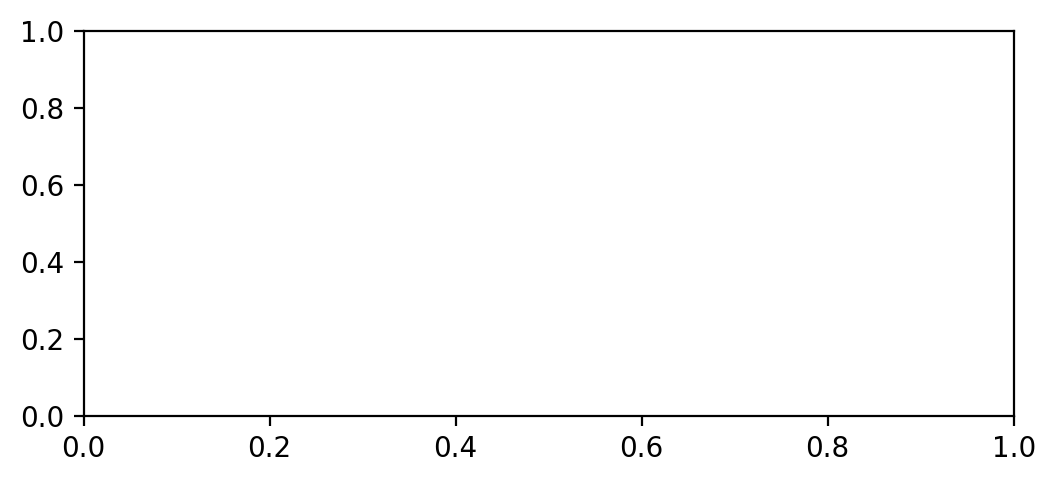

In [13]:
fig, ax = plt.subplots(figsize=(6, 2.5))
type(fig), type(ax)

- `plt.subplots()` returns two objects: the Figure and one Axes. `figsize` is
  (width, height) in inches.
- Every step after this is a method of `ax`: `ax.hist`, `ax.plot`,
  `ax.set(xlabel=...)`.

### Resolution: `retina` and `dpi`

- **dpi** means dots per inch: the number of pixels matplotlib draws for each
  inch of `figsize`. The default is 100, so a figure 6 inches wide is 600
  pixels wide.
- On a high-resolution screen, such as a Mac's Retina display, one of those
  pixels covers several screen pixels. Text and thin lines then look blurry.

In [14]:
# Pixel width and height of the last figure, at 100 dpi and at 300 dpi.
fig.get_size_inches() * 100, fig.get_size_inches() * 300

(array([600., 250.]), array([1800.,  750.]))

- `%config InlineBackend.figure_format = 'retina'` in the setup cell draws each
  figure at twice the pixel density and shows it at the same size, so lines and
  text stay sharp. `%config` is a Jupyter command, not Python. It changes only
  what the notebook shows.
- `plt.rcParams['savefig.dpi'] = 300` makes each `fig.savefig` write 300 pixels
  per inch. The 6-inch figure above becomes a file 1,800 pixels wide.

- 300 dpi is a common minimum for printed and journal figures. For slides and
  web pages, 150 to 200 dpi is usually enough.
- A vector file, such as `fig.savefig('name.pdf')` or `fig.savefig('name.svg')`,
  stores lines and text as shapes. It stays sharp at any size and needs no dpi.

### A histogram with matplotlib

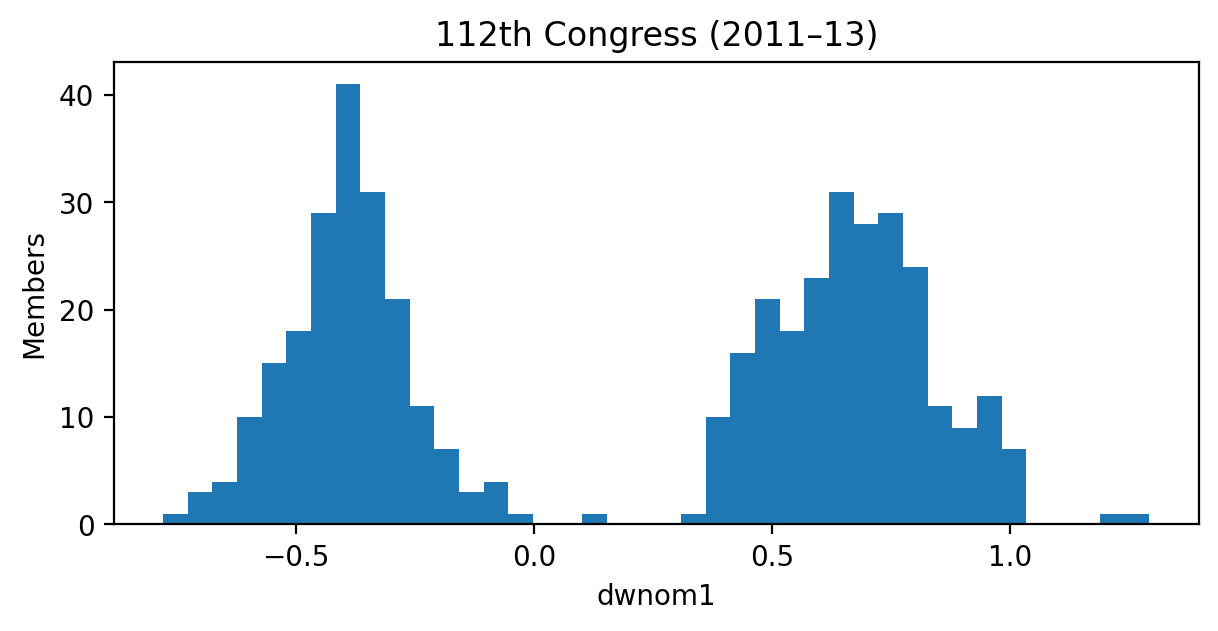

In [15]:
last = two.loc[two['congress'] == 112]

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(last['dwnom1'], bins=40)
ax.set(
    xlabel='dwnom1',
    ylabel='Members',
    title='112th Congress (2011–13)',
);

- A **histogram** divides the scores into bins and draws one bar per bin. A
  bar's height is the number of members in that bin.
- The scores form two humps with an empty stretch between them. The chart does
  not show which hump is which party, because `party` has no role in it yet.
- The `;` at the end hides the text that `ax.set` returns, so only the figure
  shows.

### A histogram with seaborn, coloured by party

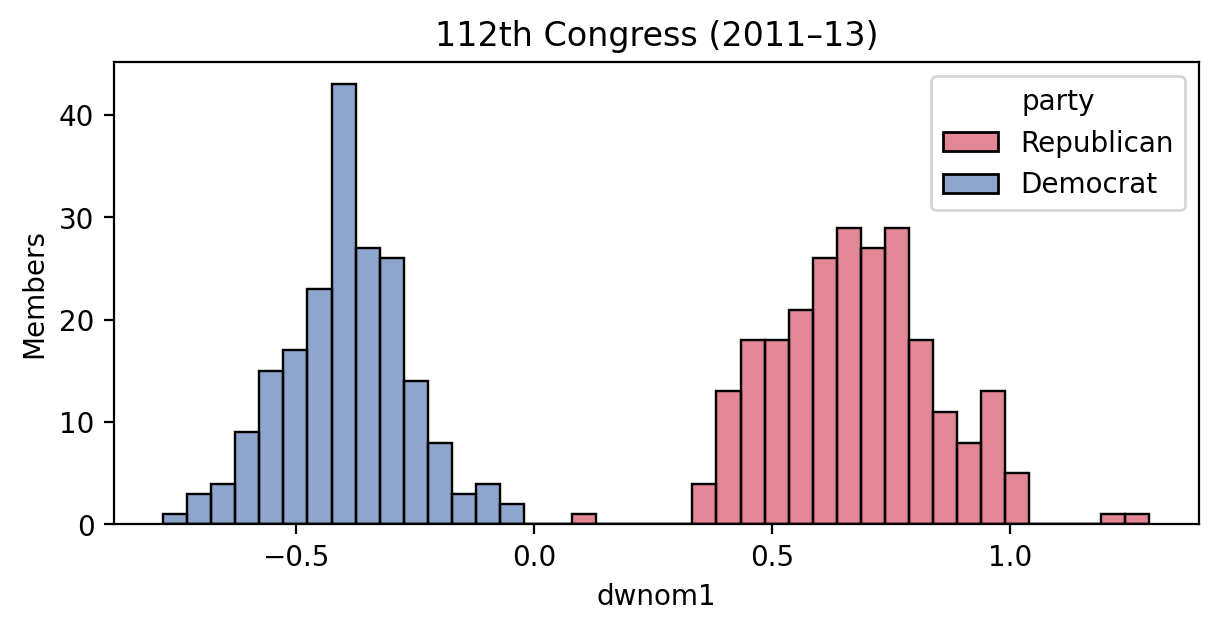

In [16]:
fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(
    data=last,
    x='dwnom1',
    hue='party',
    palette=colors,
    binwidth=0.05,
    ax=ax,
)
ax.set(
    xlabel='dwnom1',
    ylabel='Members',
    title='112th Congress (2011–13)',
);

- `data=` names the DataFrame. `x=` and `hue=` name its columns. seaborn draws
  one set of bars per party and adds the legend.
- `hue` **maps** the column `party` to colour. A mapping connects a feature to
  something the eye can see: a position, a colour, or a panel.
- `ax=ax` tells seaborn which Axes to draw on.

- In the 112th Congress, no bin holds both colours. The parties do not overlap.

### Lecture 4's figure, step 1: party medians by year

- Lecture 4 opened with a figure and the comment "You will be able to read
  every line of this by the end of next lecture." The figure's code follows in
  three parts, one per slide.

In [17]:
members = congress.loc[congress['district'] != 0].copy()
members['year'] = 1789 + 2 * (members['congress'] - 1)

medians = (
    members
    .groupby(['year', 'party'])['dwnom1']
    .median()
    .unstack()
)
medians.head(3)

party,Democrat,Other,Republican
year,,,
1947,-0.1240,-0.7815,0.266
1949,-0.2065,-0.6210,0.262
1951,-0.1760,-0.0960,0.261


- `year` is the first year of each Congress. The 1st Congress met in 1789, and a
  new one starts every two years.
- `groupby` followed by `.unstack()` is last lecture's long-to-wide move: one
  row per year, one column per party.

### Lecture 4's figure, step 2: a scatter plot of members

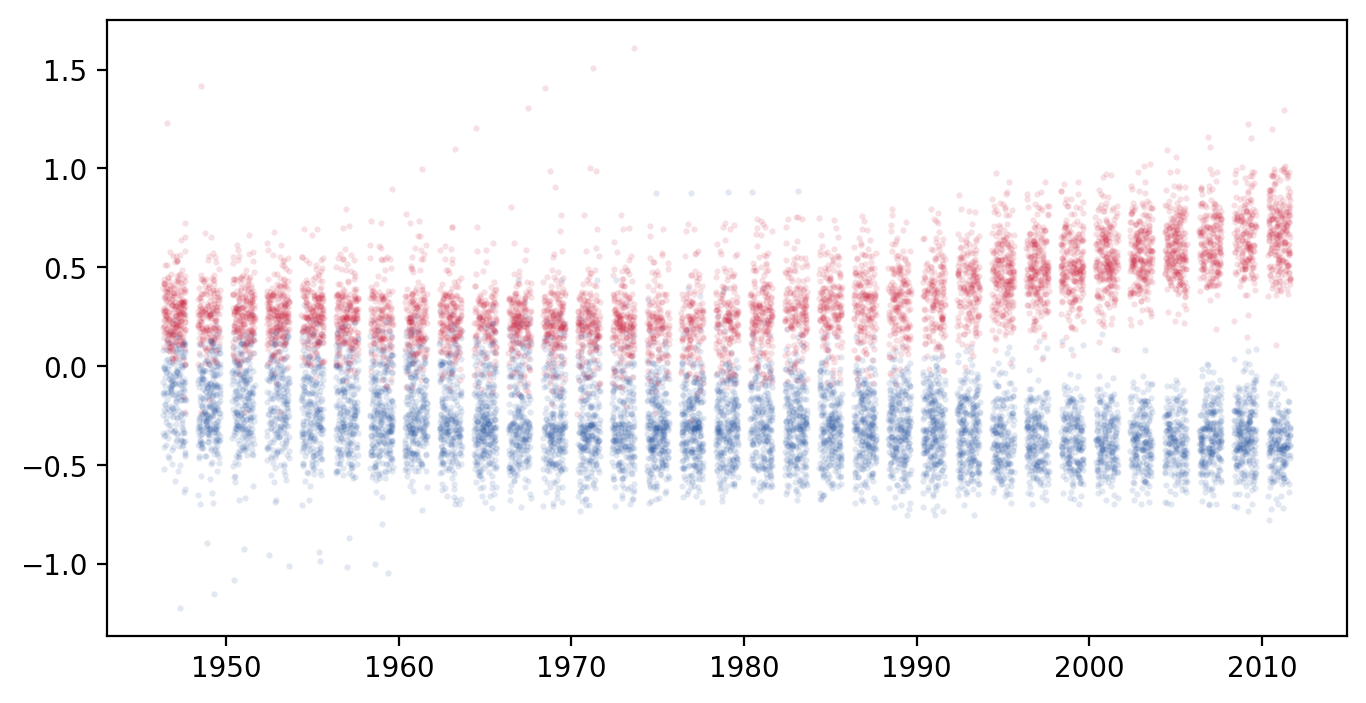

In [18]:
import numpy as np

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(8, 4))

for party, colour in [('Democrat', '#1f4e9c'), ('Republican', '#c8102e')]:
    side = members.loc[members['party'] == party]
    jitter = rng.uniform(-0.65, 0.65, len(side))
    ax.scatter(
        side['year'] + jitter,
        side['dwnom1'],
        s=5,
        color=colour,
        alpha=0.13,
        linewidths=0,
        zorder=1,
    )

- The loop draws one party at a time, each in its own colour.
- `ax.scatter(x, y)` draws one dot per row. Everyone in a Congress shares a
  year, so `rng.uniform` adds a small random shift to each x value (a
  **jitter**). Without it the dots would land on top of each other.
- `s` is the dot size and `alpha` the opacity. At 0.13 each dot is faint, so
  crowded areas look darker. `zorder` sets which marks sit on top.

### Lecture 4's figure, step 3: median lines and labels

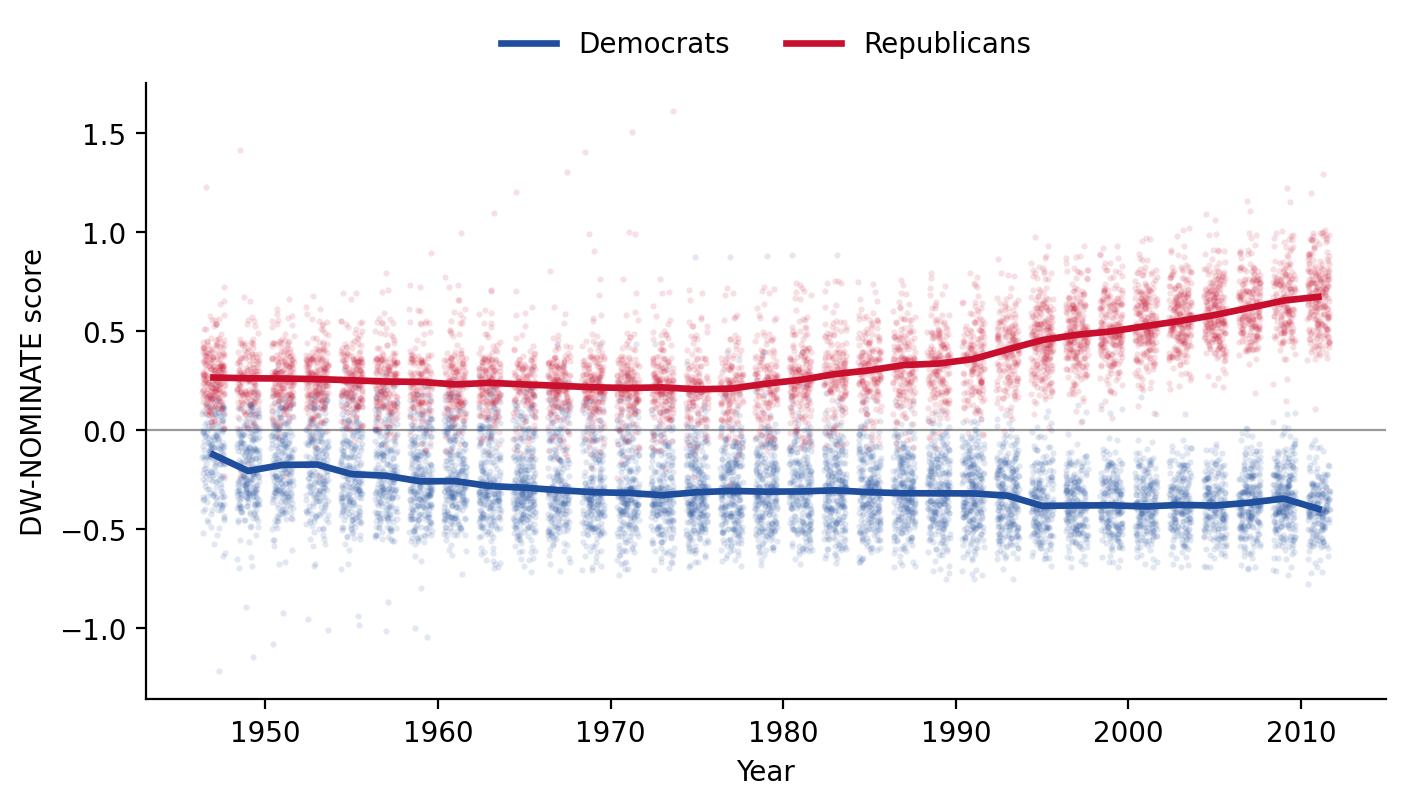

In [19]:
median_lines = [
    ('Democrat', '#1f4e9c', 'Democrats'),
    ('Republican', '#c8102e', 'Republicans'),
]
for party, colour, label in median_lines:
    ax.plot(
        medians.index,
        medians[party],
        color=colour,
        linewidth=2.4,
        zorder=3,
        label=label,
    )

ax.axhline(0, color='#999999', linewidth=0.8, zorder=0)
ax.set(xlabel='Year', ylabel='DW-NOMINATE score')
ax.legend(
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
)
ax.spines[['top', 'right']].set_visible(False)
fig

- `ax.plot(x, y)` draws a line through the party medians. `label=` is the text
  the legend shows.
- `ax.axhline(0)` draws a horizontal line at zero. `ax.legend` places the
  legend above the plot. The last `ax` line removes the top and right borders.
- `fig` on its own line shows the Figure again, now with the lines on it.

### Plotting with `DataFrame.plot`

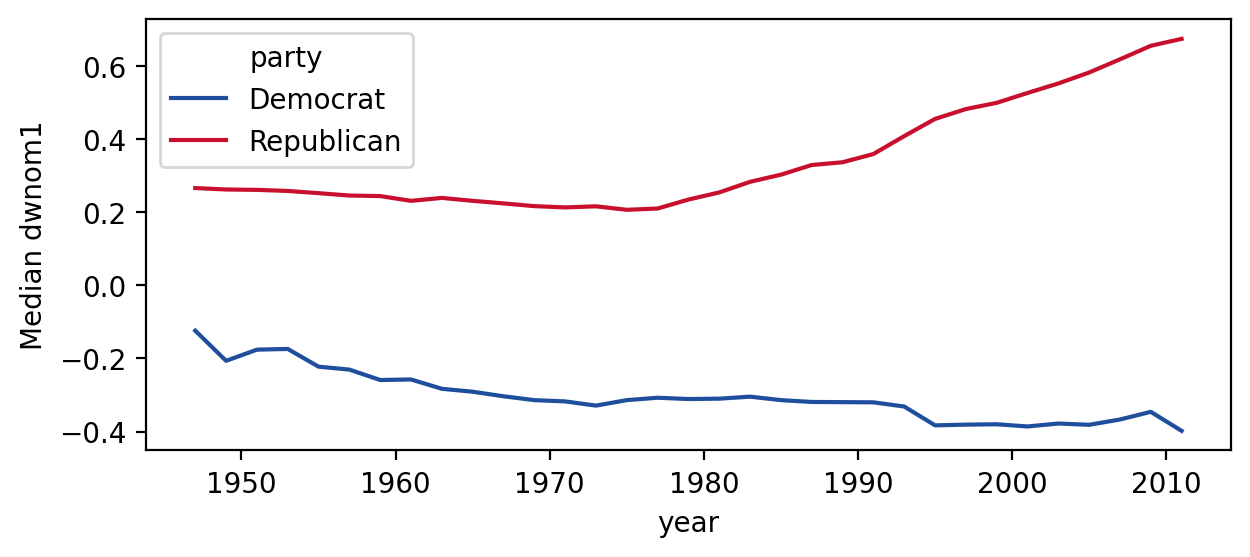

In [20]:
medians[['Democrat', 'Republican']].plot(
    color=colors,
    figsize=(7, 2.8),
    ylabel='Median dwnom1',
);

- `DataFrame.plot` draws one line per column, with the index on the x-axis. It
  calls matplotlib and returns the `Axes`.
- Use it for a quick first look. For a figure that a reader will see, start
  from `fig, ax` so you control every part.

## Bar charts

A bar chart compares **one number per category**: a count, a mean, a share.

In [21]:
seats = (
    house
    .loc[house['congress'].isin([80, 112])]
    .pivot_table(
        index='congress',
        columns='party',
        values='name',
        aggfunc='size',
        fill_value=0,
    )
)
seats

party,Democrat,Other,Republican
congress,,,
80,193,2,250
112,199,0,243


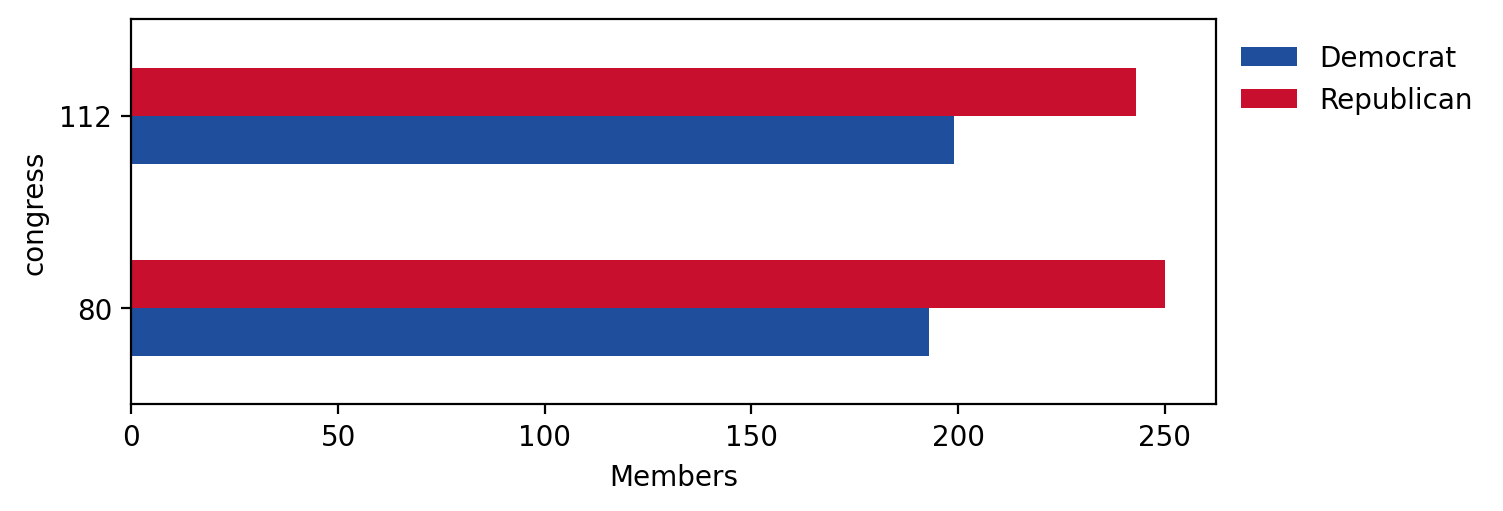

In [22]:
ax = seats[['Democrat', 'Republican']].plot.barh(
    color=colors,
    figsize=(7, 2.5),
    xlabel='Members',
)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False);

- `.plot.barh()` draws horizontal bars, one group of bars per row of the table.
- Each bar is one number, so a bar chart hides the members, as a mean does.
  It shows how many members each party had. It cannot show where they sat.

## Histograms

A histogram shows where the members are. Two choices come next: which members
share a histogram, and how wide its bins are.

### All 33 Congresses in one histogram

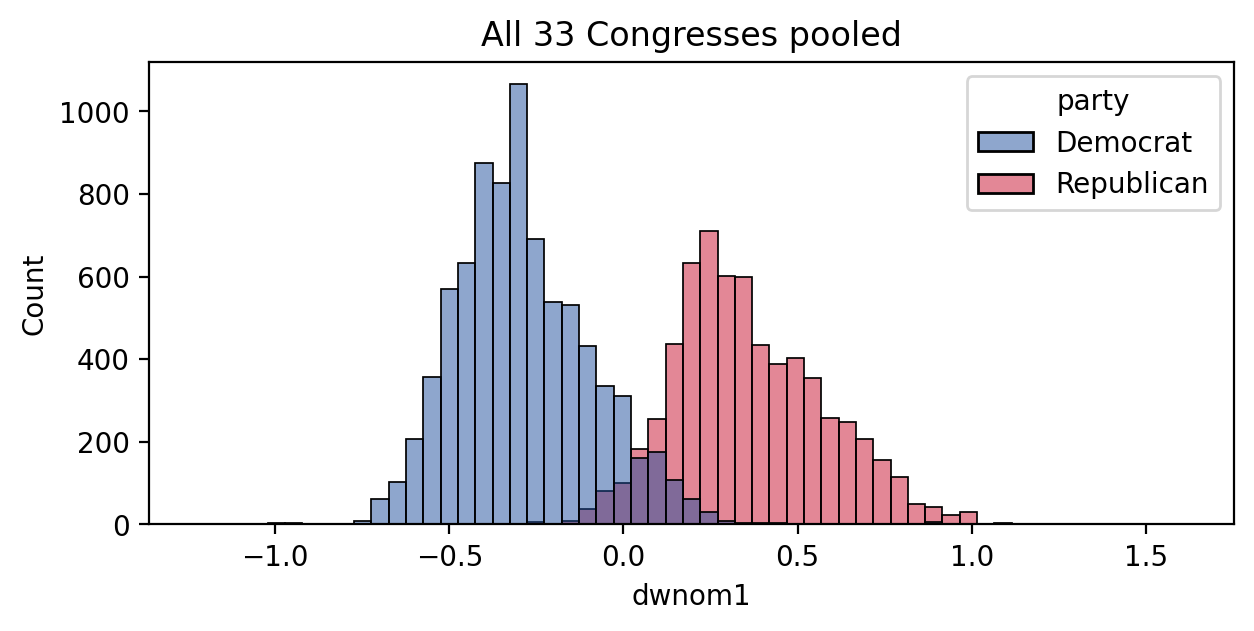

In [23]:
fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(
    data=two,
    x='dwnom1',
    hue='party',
    palette=colors,
    binwidth=0.05,
    ax=ax,
)
ax.set(title='All 33 Congresses pooled');

- The overlap looks wide, partly because members from different decades share
  bins.
- The question is about change **over time**, so time needs a place in the
  chart.

### Small multiples: one panel per Congress

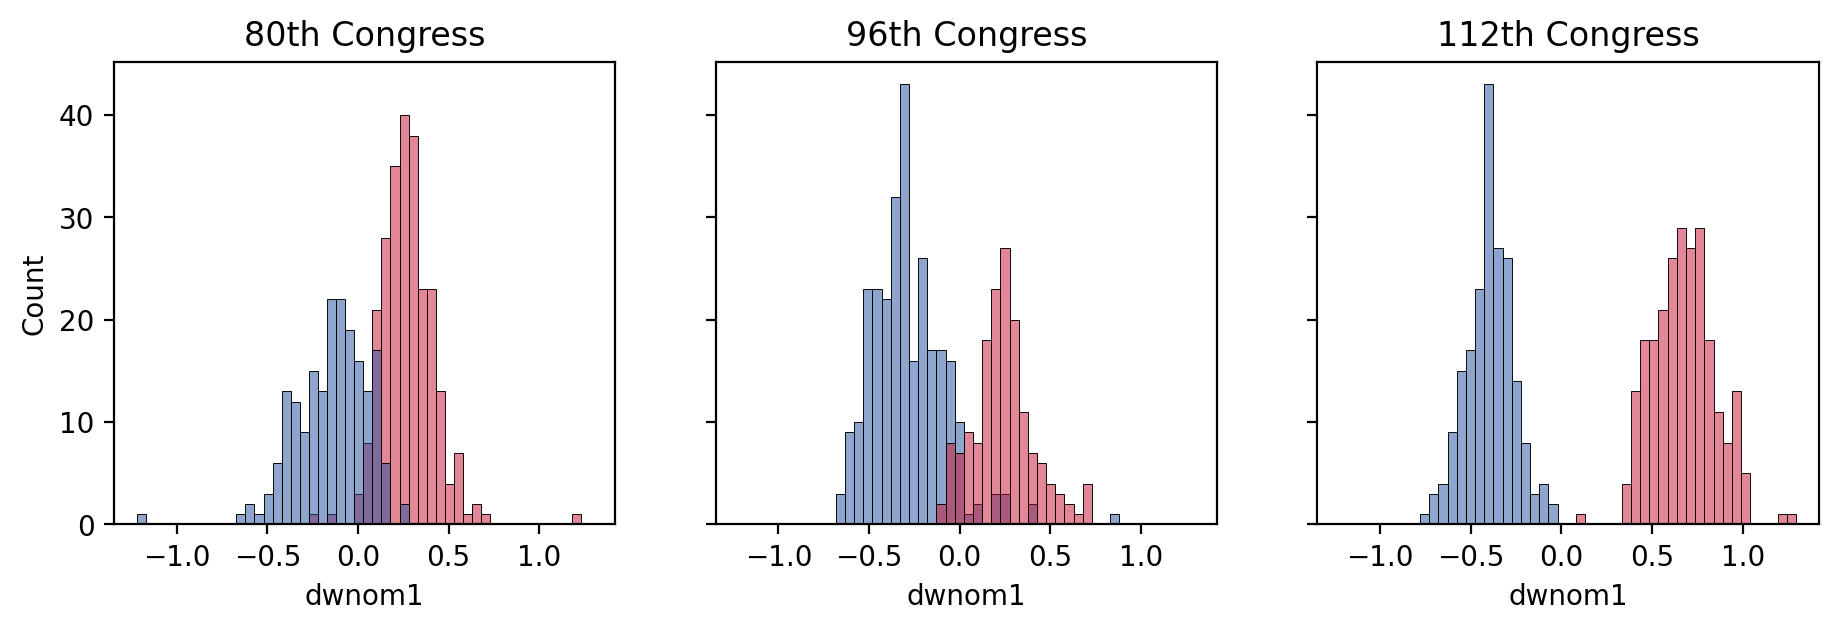

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharex=True, sharey=True)

for ax, c in zip(axes, [80, 96, 112]):
    sns.histplot(
        data=two.loc[two['congress'] == c],
        x='dwnom1',
        hue='party',
        palette=colors,
        binwidth=0.05,
        legend=False,
        ax=ax,
    )
    ax.set(title=f'{c}th Congress', xlabel='dwnom1')

- `plt.subplots(1, 3)` makes one Figure with three Axes, returned as an array.
  `zip` pairs each Axes with one Congress.
- `sharex=True, sharey=True` put the panels on the same scales, so the eye can
  compare them. Without it, each panel picks its own range.
- The panels map `congress` to **panel**. The overlap shrinks from the 80th to
  the 96th and is gone in the 112th.

<div class="alert alert-info">

**Key idea.** A pooled histogram mixes groups that the question keeps apart.
Give each group its own panel, on shared axes.

</div>

### Bin width

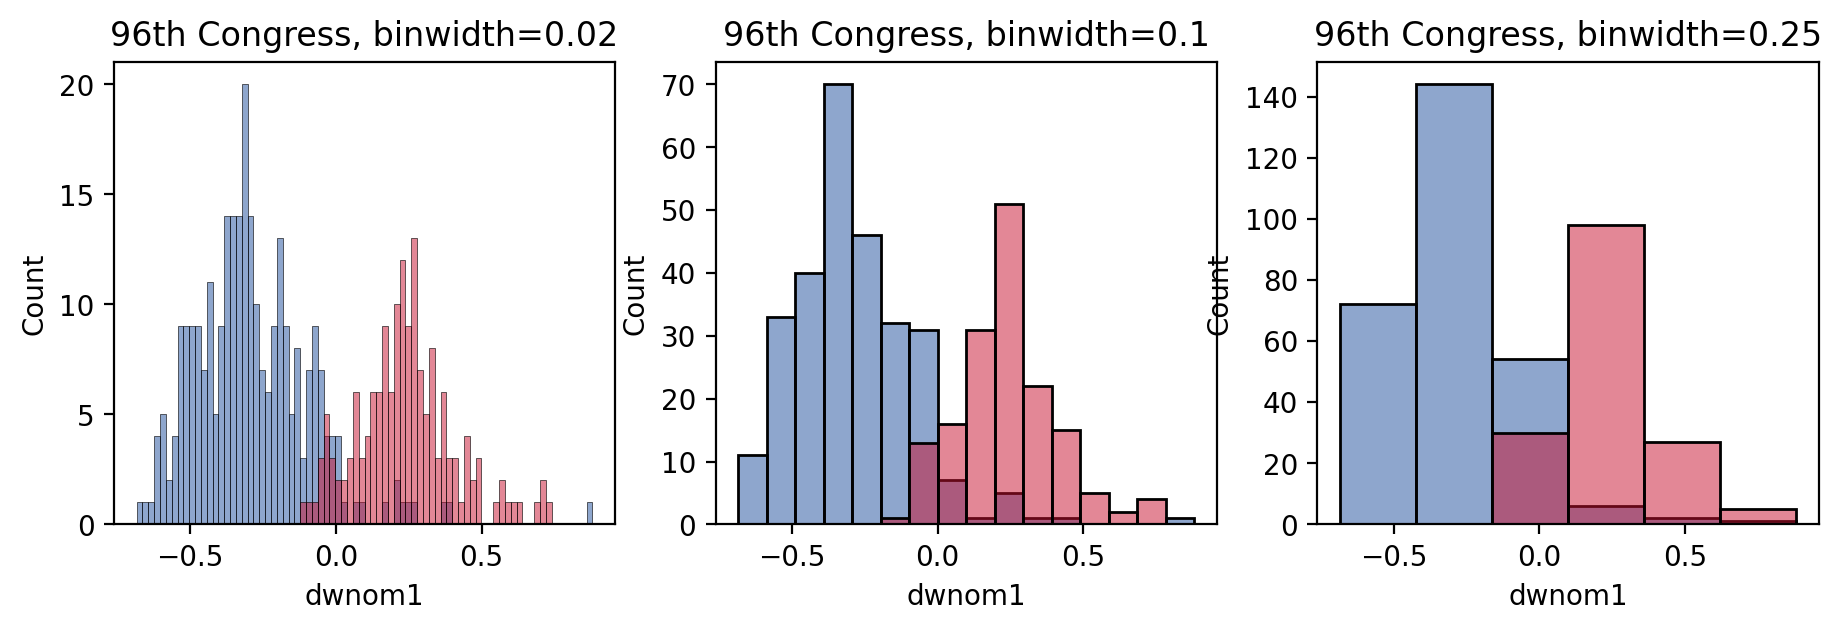

In [25]:
mid = two.loc[two['congress'] == 96]

fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharex=True)

for ax, width in zip(axes, [0.02, 0.1, 0.25]):
    sns.histplot(
        data=mid,
        x='dwnom1',
        hue='party',
        palette=colors,
        binwidth=width,
        legend=False,
        ax=ax,
    )
    ax.set(title=f'96th Congress, binwidth={width}')

- Narrow bins show detail and noise. Wide bins smooth away both.
- No single bin width is the right one. Trust a claim that holds at several
  widths.

<div class="alert alert-success">

### Activity 1 · Which claims hold at every bin width?

Look at the three panels of the 96th Congress (1979–81). For each claim,
decide whether it holds in **all three** panels.

1. The two parties overlap.
2. Most Republicans score above 0.
3. The Republican scores form one peak.
4. There is an empty stretch between the two parties.

Name one claim that depends on the bin width. Try a fourth width in the cell
below if you are not sure.

</div>

### Activity 1 answers

- **Survive every width:** the parties overlap (claim 1), and most Republicans
  score above 0 (claim 2).
- **Depends on the width:** at 0.02 the Republican scores look jagged, with
  several small peaks; at 0.1 and 0.25 they form one hump (claim 3).
- **Fails:** there is no empty stretch between the parties in the 96th
  (claim 4). That is a 112th-Congress feature.

## Box plots and violin plots

Histograms need one panel per Congress. A box plot fits many groups in one
chart.

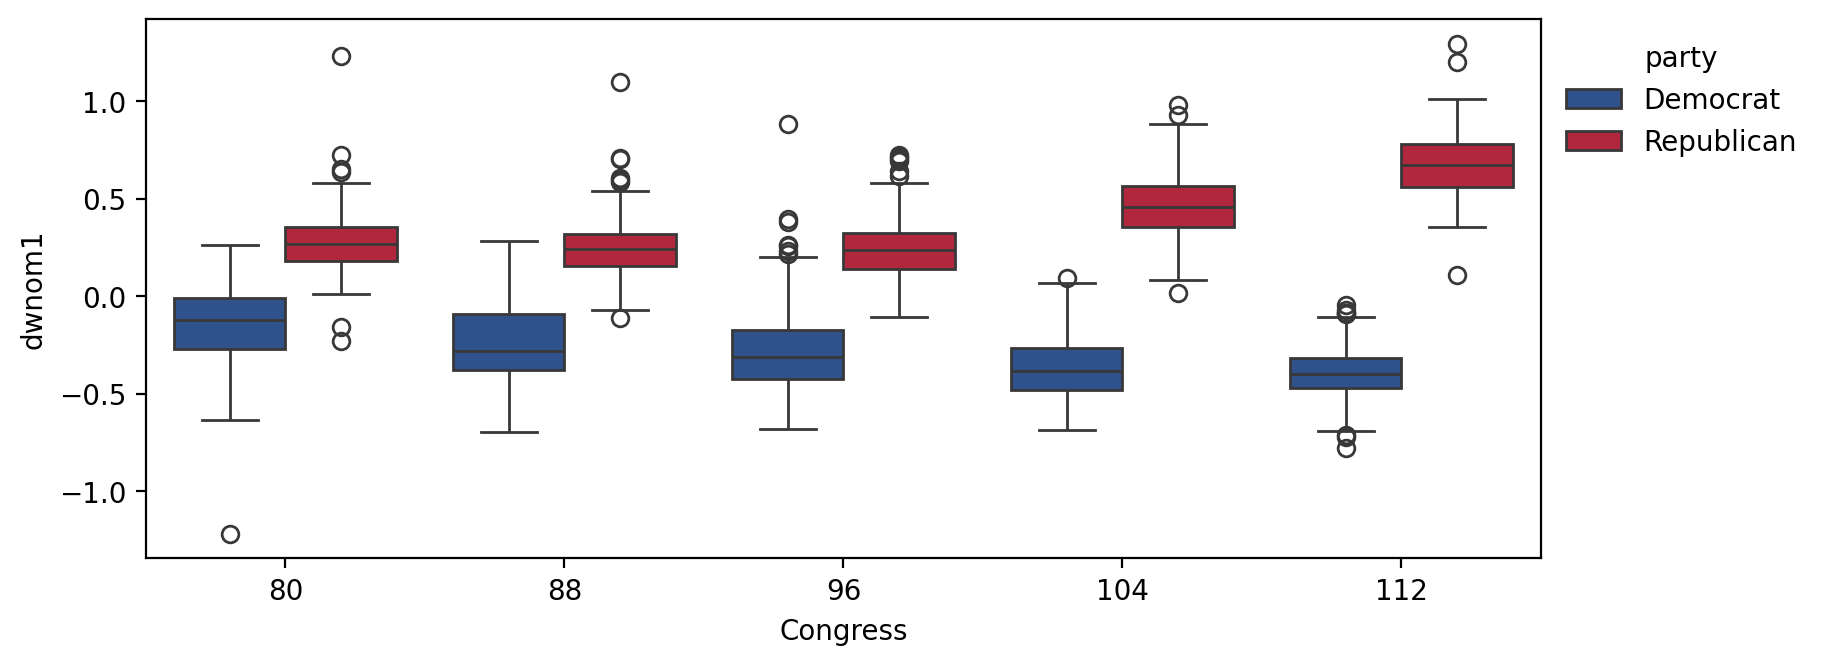

In [26]:
five = two.loc[two['congress'].isin([80, 88, 96, 104, 112])]

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.boxplot(
    data=five,
    x='congress',
    y='dwnom1',
    hue='party',
    palette=colors,
    ax=ax,
)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), frameon=False)
ax.set(xlabel='Congress', ylabel='dwnom1');

- A box shows five numbers. The line is the median. The box spans the middle
  half of the members, from the 25th to the 75th percentile. The whiskers
  reach the rest, and dots mark members far outside the box.
- `sns.move_legend` moves seaborn's legend outside the plot, so it covers no
  box.
- The Republican boxes rise from one Congress to the next. The Democratic boxes
  get **shorter**: the middle half of Democrats spans 0.26 in the 80th and 0.15
  in the 112th.

### Violin plots

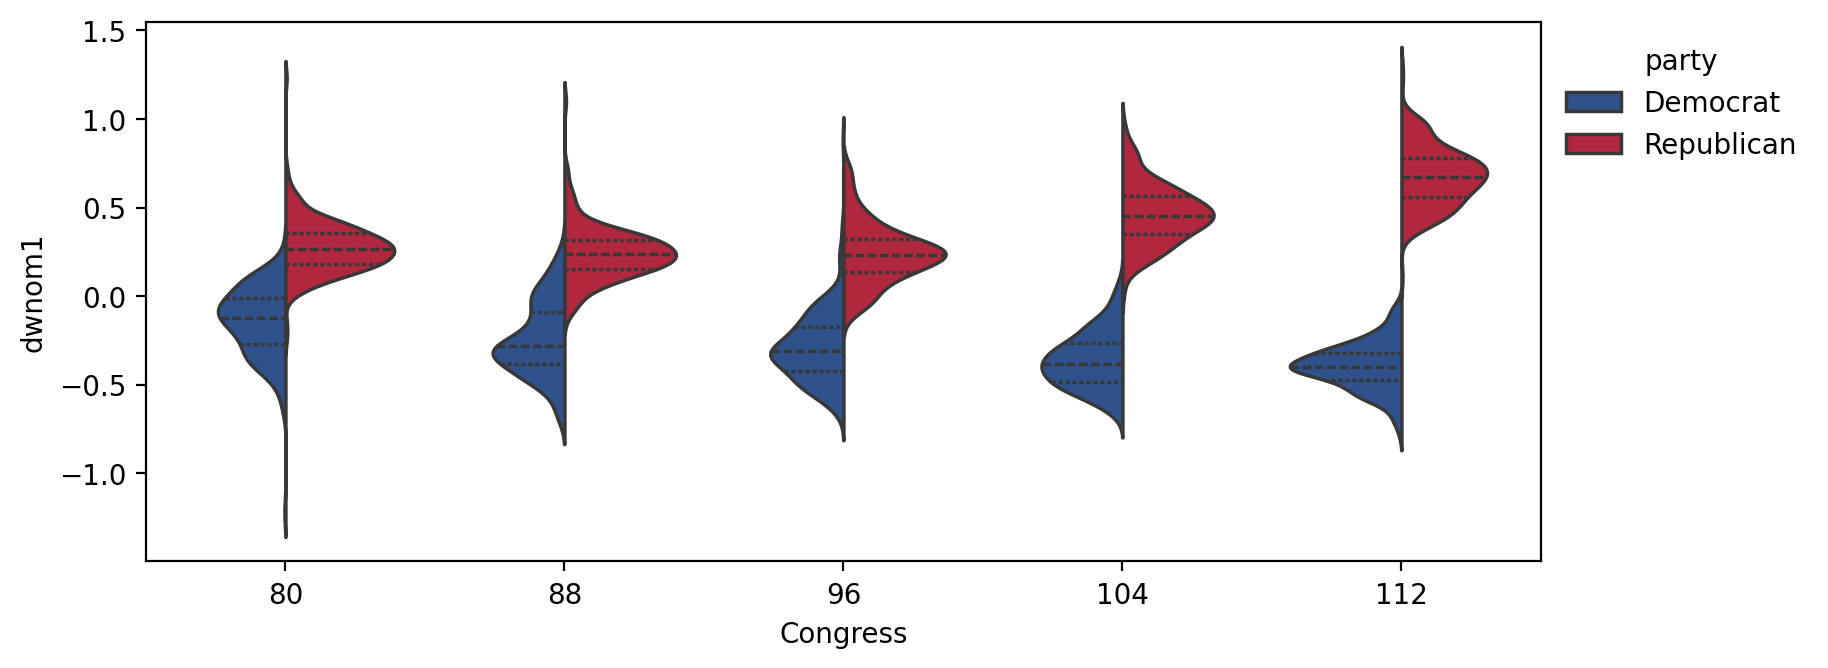

In [27]:
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.violinplot(
    data=five,
    x='congress',
    y='dwnom1',
    hue='party',
    palette=colors,
    split=True,
    inner='quart',
    ax=ax,
)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), frameon=False)
ax.set(xlabel='Congress', ylabel='dwnom1');

- A **violin plot** draws a smoothed histogram on its side. `split=True` puts
  one party on each half; the dashed lines are the quartiles.
- In the 80th Congress the Democratic half is lopsided: a peak near -0.1 and a
  wide shoulder to the left. A box cannot show that.
- Lecture 4's activity found one reason: Southern Democrats averaged -0.027,
  well to the right of other Democrats at -0.285. On one score, the two groups
  overlap. The next slide adds a second score.

## Scatter plots

- `dwnom1` places members on the main left-right dimension of roll-call
  voting.
- `dwnom2` is a second score estimated from the same votes. In these decades it
  mostly captured splits **within** the parties by region, including votes on
  civil rights.

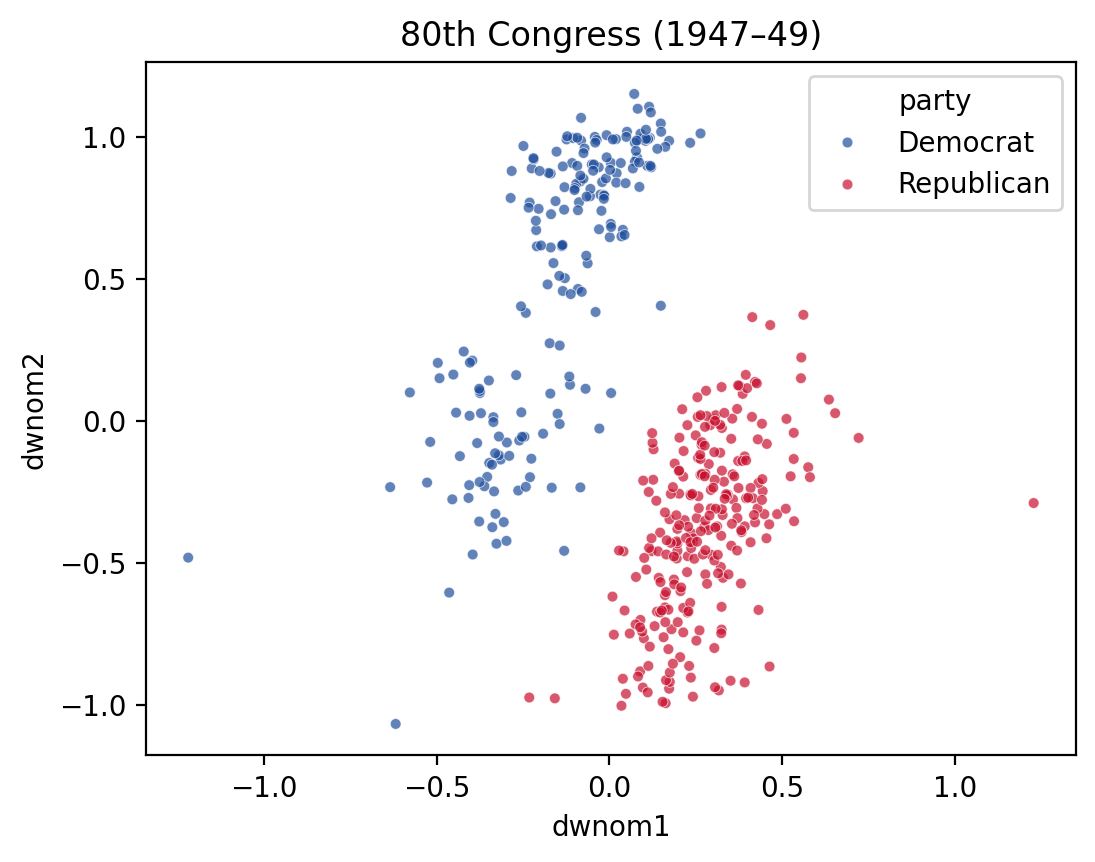

In [28]:
first = two.loc[two['congress'] == 80]

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.scatterplot(
    data=first,
    x='dwnom1',
    y='dwnom2',
    hue='party',
    palette=colors,
    s=15,
    alpha=0.7,
    ax=ax,
)
ax.set(title='80th Congress (1947–49)');

- A scatter plot maps two numerical features to x and y position: one dot per
  member.
- The Democrats form **two clouds**, one low on `dwnom2` and one high. The activity
  asks who is in the upper cloud.

## Line charts: overlapping Democrats over time

- Define an **overlapping Democrat**: a Democrat whose `dwnom1` is higher than
  the lowest Republican score in the same Congress.
- The count for one Congress needs both parties at once, so it is a job for
  `apply` (last lecture's fourth grouping method).

In [29]:
def overlap(one):
    rep_min = one.loc[one['party'] == 'Republican', 'dwnom1'].min()
    dem_scores = one.loc[one['party'] == 'Democrat', 'dwnom1']
    return (dem_scores > rep_min).sum()

overlapping = house.groupby('congress')[['party', 'dwnom1']].apply(overlap)
overlapping

congress
80     134
81     144
82     138
83     126
      ... 
109      0
110      0
111      0
112      0
Length: 33, dtype: int64

<div class="alert alert-success">

### Activity 2 · When did the overlap end?

Draw `overlapping` as a line chart with `fig, ax` and label both axes. Then
answer:

1. In which Congress does the count first reach 0?
2. Does the count fall steadily, or in a few large steps?
3. Look at the largest single drop. Use `groupby` and `.idxmin()` to find the
   most liberal Republican in the Congress before the drop and in the Congress
   after it. What changed?

</div>

### Overlapping Democrats by Congress

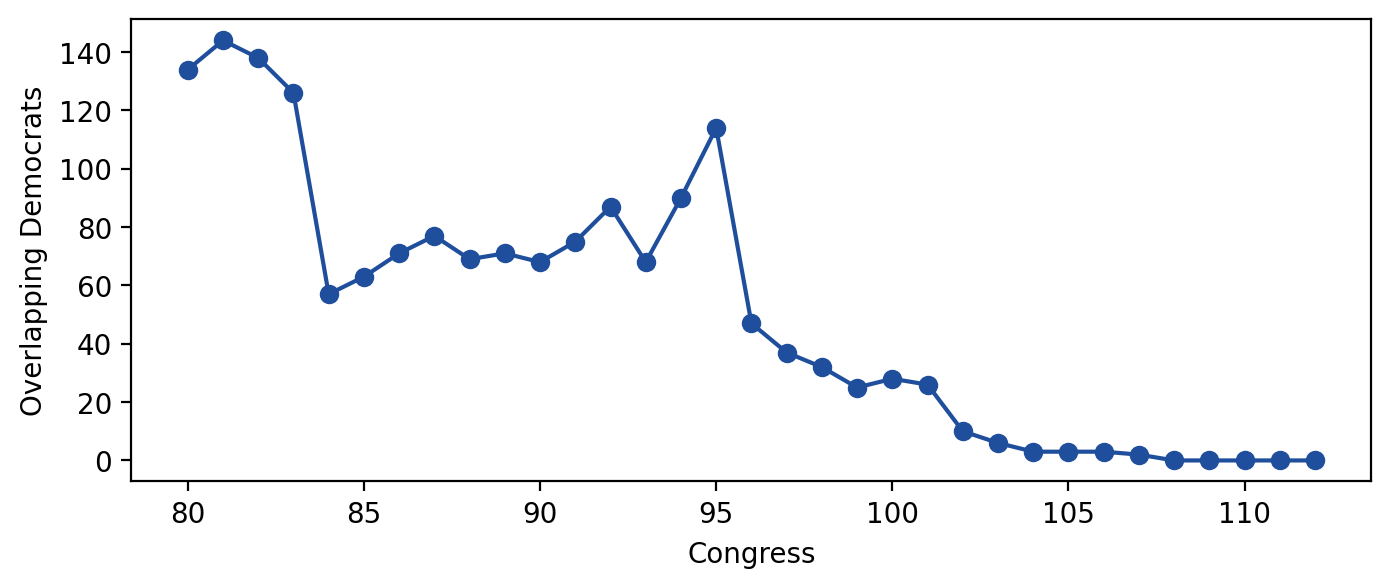

In [30]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(overlapping.index, overlapping, marker='o', color='#1f4e9c')
ax.set(xlabel='Congress', ylabel='Overlapping Democrats');

In [31]:
overlapping.loc[overlapping == 0].index.min()

108

- **134** overlapping Democrats in the 80th Congress, **47** in the 96th, **3**
  in the 104th, and **none** from the 108th (2003–05) on.
- The count falls in steps, and the largest one is from 126 in the 83rd to 57
  in the 84th.

### The most liberal Republican in each Congress

In [32]:
reps = two.loc[two['party'] == 'Republican']
most_liberal = reps.loc[reps.groupby('congress')['dwnom1'].idxmin()]

(most_liberal
    .set_index('congress')
    .loc[[83, 84, 107, 108], ['name', 'state', 'dwnom1']])

,name,state,dwnom1
congress,,,
83,JAVITS,NEW YOR,-0.232
84,CANFIELD,NEW JER,-0.054
107,MORELLA,MARYLAN,0.080
108,LEACH,IOWA,0.210


- Jacob Javits of New York (-0.232) was the most liberal Republican through the
  83rd Congress. He left the House in 1954, and the line fell by 69.
- Constance Morella of Maryland held that place from the 102nd to the 107th
  Congress. She lost her seat in 2002, and the count went from 2 to 0.
- **One** Republican sets the threshold for the whole count, the same problem
  McDonald caused with the maximum. A count built on an extreme member moves when that member
  leaves.

### Party medians and spread by Congress

- To see the whole party, not its most extreme member, follow its median and
  its spread.

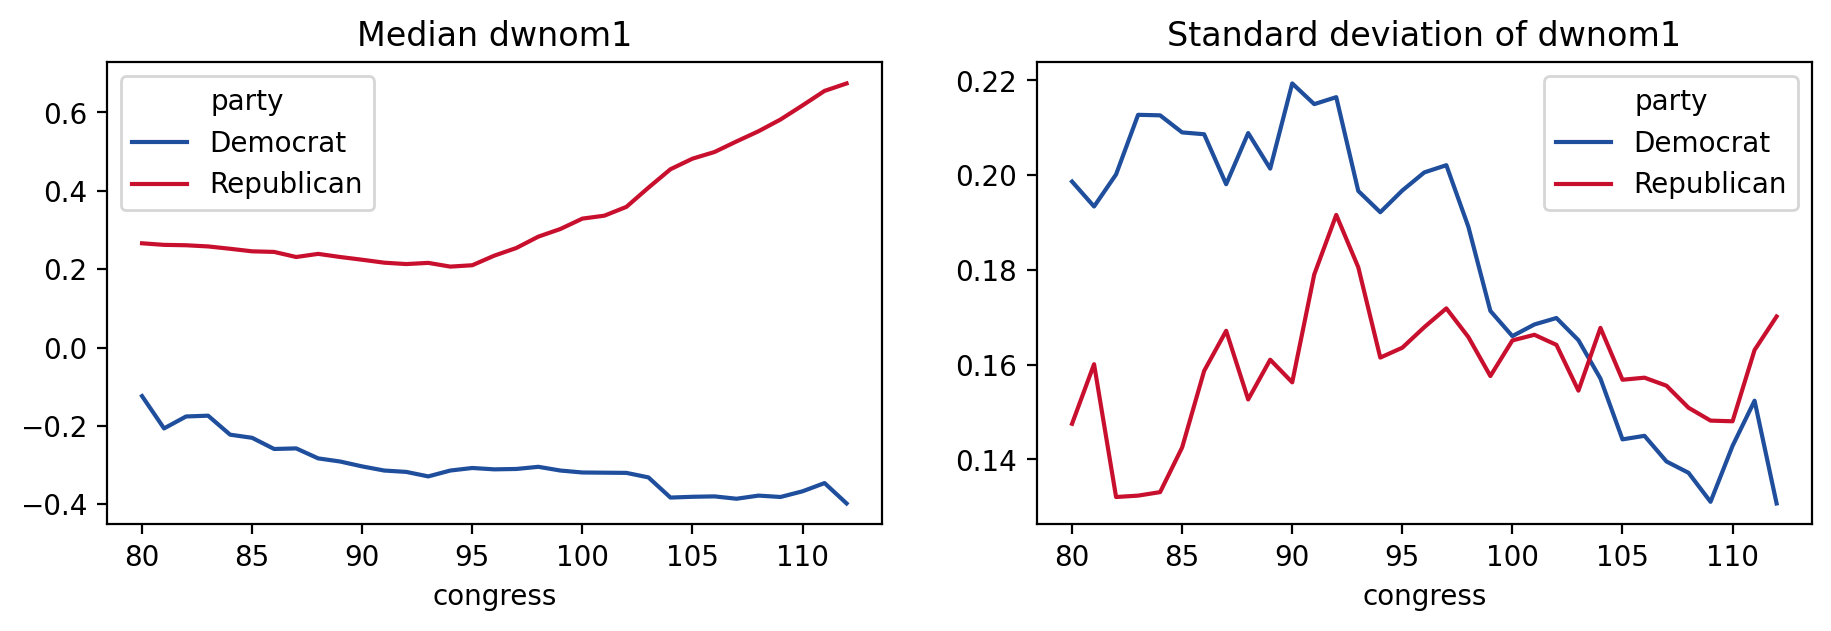

In [33]:
summary = two.pivot_table(
    index='congress',
    columns='party',
    values='dwnom1',
    aggfunc=['median', 'std'],
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
summary['median'].plot(
    ax=axes[0],
    color=colors,
    title='Median dwnom1',
)
summary['std'].plot(
    ax=axes[1],
    color=colors,
    title='Standard deviation of dwnom1',
);

In [34]:
summary.loc[[80, 112]].round(2)

median                 std           
party    Democrat Republican Democrat Republican
congress                                        
80          -0.12       0.27     0.20       0.15
112         -0.40       0.67     0.13       0.17

- **Republicans:** the median rose from 0.27 to 0.67. The spread moved between
  0.13 and 0.19 with no trend, 0.15 in the 80th and 0.17 in the 112th. The
  whole party moved right **as a block**.
- **Democrats:** the median fell from -0.12 to -0.40. The spread stayed near
  0.20 until the late 1980s, then fell to 0.13. The party lost its
  conservative wing and became more alike.

### Making a figure for a reader

- You make **exploratory** figures for yourself: many of them, fast, with
  default labels.
- A figure for a **reader** needs a title that states the finding, labeled
  axes, and a source note. It also needs a readable size, and alt text for
  anyone who cannot see it. Save it to a file.

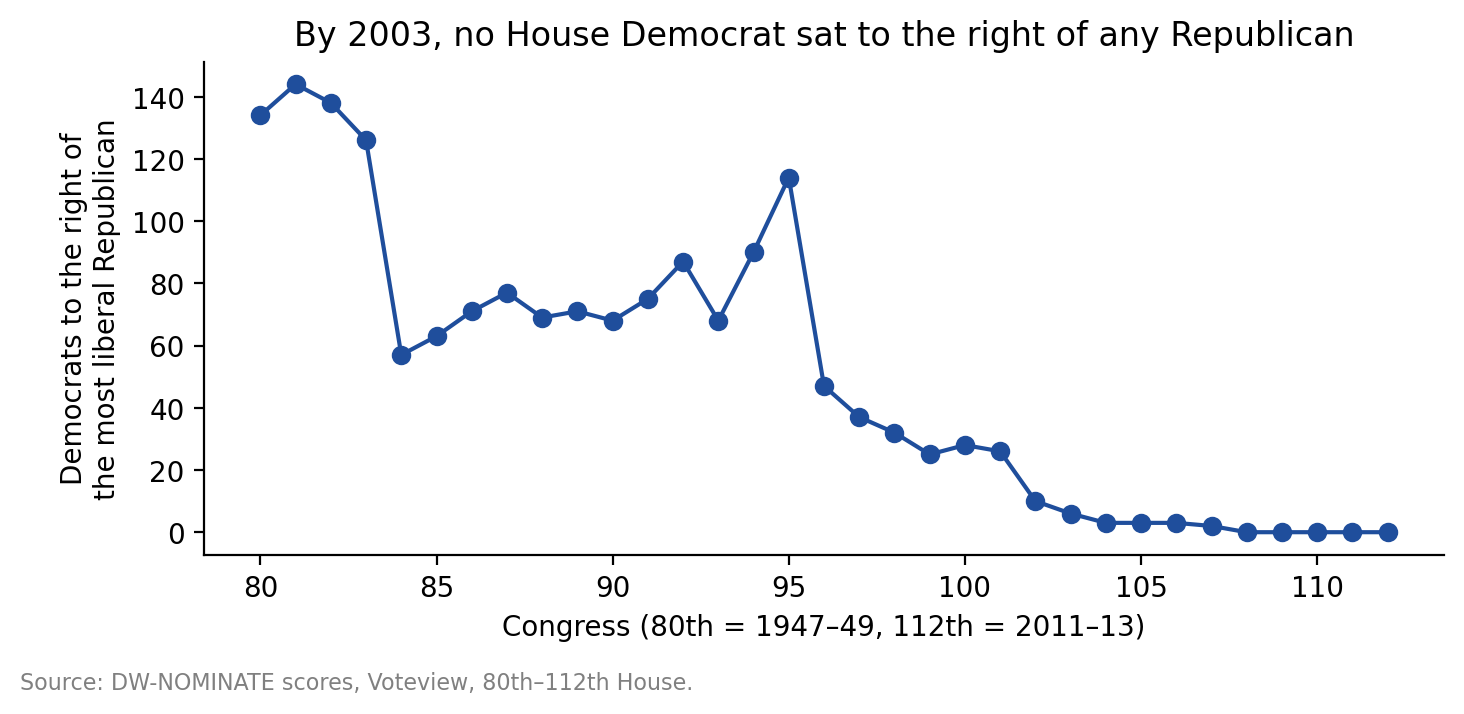

In [35]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(overlapping.index, overlapping, marker='o', color='#1f4e9c')
ax.set(
    title='By 2003, no House Democrat sat to the right of any Republican',
    xlabel='Congress (80th = 1947–49, 112th = 2011–13)',
    ylabel='Democrats to the right of\nthe most liberal Republican',
)
ax.spines[['top', 'right']].set_visible(False)

fig.text(
    0.01, -0.1,
    'Source: DW-NOMINATE scores, Voteview, 80th–112th House.',
    fontsize=8,
    color='grey',
)
fig.savefig('images/overlap.png', dpi=300, bbox_inches='tight')

- `fig.savefig` writes the file. `dpi=300` repeats the setup cell's default,
  so the line still works when you copy it into another notebook.
- `bbox_inches='tight'` trims the empty margin and keeps the source note inside
  the image.
- In a notebook or a report, the alt text goes in the image link:
  `![Line chart: overlapping Democrats fall from 134 in 1947 to 0 in 2003](images/overlap.png)`.

## Missing values in the Florida voter file

- **New question:** which Florida voters have no recorded race, and what should
  an analysis do with them?
- **New row unit:** one **registered voter**. The file holds 10,000 records from
  the Florida voter file, prepared by Imai and Khanna (2016).
- **What stays the same:** `read_csv`, selection, `groupby`, and today's charts.
- **What changes:** the rows are people, not members of Congress, and some cells
  are empty.

- Florida's registration form asks for race and ethnicity, so the file records
  it for most voters. Most states do not ask, and a researcher studying turnout
  or representation by race then has to estimate it.
- Most voters have a recorded race, so we can see who is missing one.

### The voter file

| Column | What it holds |
|---|---|
| `surname` | last name, in capitals |
| `county` | county code (Florida has 67 counties) |
| `VTD` | voting district within the county |
| `age` | age in years |
| `gender` | `f` or `m` |
| `race` | `white`, `black`, `hispanic`, `asian`, `native`, `other` |

In [36]:
voters = pd.read_csv('../../data/raw/FLVoters.csv')
voters

,surname,county,VTD,age,gender,race
0,PIEDRA,115,66,58.0,f,white
1,LYNCH,115,13,51.0,m,white
2,CHESTER,115,103,63.0,m,NaN
3,LATHROP,115,80,54.0,m,white
...,...,...,...,...,...,...
9996,HILBERS,15,87,66.0,f,white
9997,JOHNSON,33,158,45.0,f,black
9998,GIL,86,1247,47.0,f,hispanic
9999,DAVIS,71,55,62.0,m,white


### Counting missing values

In [37]:
voters.isna().sum()

surname      1
county       0
VTD          0
age          8
gender       8
race       874
dtype: int64

- `.isna()` gives `True` for every missing cell. `.sum()` counts the `True`
  values in each column.
- 874 of 10,000 voters, 8.7 percent, have no recorded race.

In [38]:
voters['race'].value_counts(dropna=False)

race
white       6217
black       1197
hispanic    1193
NaN          874
other        315
asian        175
native        29
Name: count, dtype: int64

- `dropna=False` keeps `NaN` as its own row. Without it, `value_counts` skips
  missing values and says nothing about them.

### How `read_csv` decides what is missing

In [39]:
voters.loc[voters['surname'].isna()]

,surname,county,VTD,age,gender,race
349,NaN,5,14,70.0,f,white


In [40]:
with open('../../data/raw/FLVoters.csv') as f:
    lines = f.readlines()

lines[0], lines[350], lines[3]

('"surname","county","VTD","age","gender","race"\n',
 '"NULL",5,14,70,"f","white"\n',
 '"CHESTER",115,103,63,"m",NA\n')

- `lines[350]` is the voter whose surname is `NULL`. `lines[3]` has `NA` where
  the race should be. The first is a name; the second marks a missing value.
- `keep_default_na=False` turns off the default list. `na_values=['NA']` names
  the one string that means missing in this file.

In [41]:
voters = pd.read_csv(
    '../../data/raw/FLVoters.csv',
    keep_default_na=False,
    na_values=['NA'],
)
voters.isna().sum()

surname      0
county       0
VTD          0
age          8
gender       8
race       874
dtype: int64

<div class="alert alert-info">

**Key idea.** `read_csv` decides what counts as missing when it reads the file.
Look at the raw text behind every `NaN` before you trust the count.

</div>

### Missing race by gender

- If missing race were unrelated to everything else, dropping those voters
  would not change any comparison. Check that before you rely on it.

In [42]:
flagged = voters.assign(no_race=voters['race'].isna())
flagged.groupby('gender')['no_race'].mean()

gender
f    0.088076
m    0.086769
Name: no_race, dtype: float64

- 8.8 percent of women and 8.7 percent of men have no recorded race: no
  difference by gender.
- `groupby` leaves out rows whose key is missing, so the 8 voters with no
  gender do not appear.

### Missing race by age

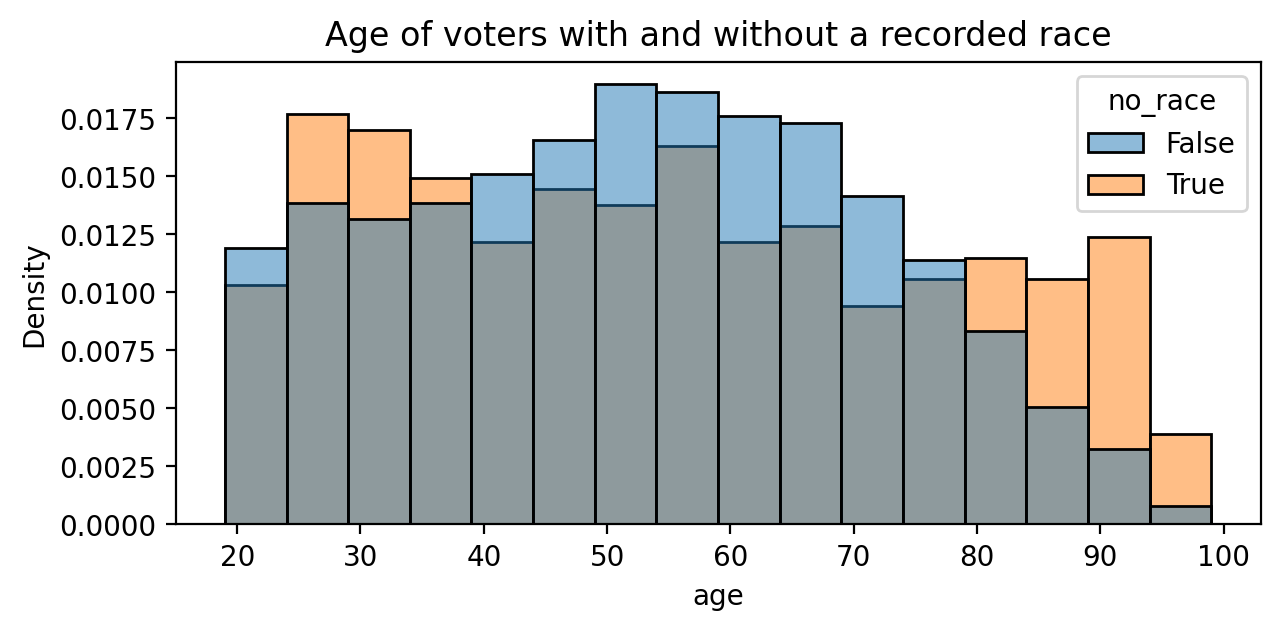

In [43]:
fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(
    data=flagged,
    x='age',
    hue='no_race',
    binwidth=5,
    stat='density',
    common_norm=False,
    ax=ax,
)
ax.set(title='Age of voters with and without a recorded race');

In [44]:
flagged.groupby('no_race')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
no_race,,,,,,,,
False,9121.0,52.418156,18.486782,19.0,37.0,53.0,66.0,99.0
True,871.0,54.616533,21.818265,19.0,35.0,53.0,73.0,99.0


- The medians match (53), but voters with no race are more spread out in age.
  Their 75th percentile is 73 against 66, and their 25th is 35 against 37.
- `stat='density', common_norm=False` again. Without it, the 874 voters would
  be too small to see next to the 9,126.

### Missing race by county

- Counties with few voters in the sample give noisy shares. Keep counties with
  at least 100 voters first, with `filter` from last lecture.

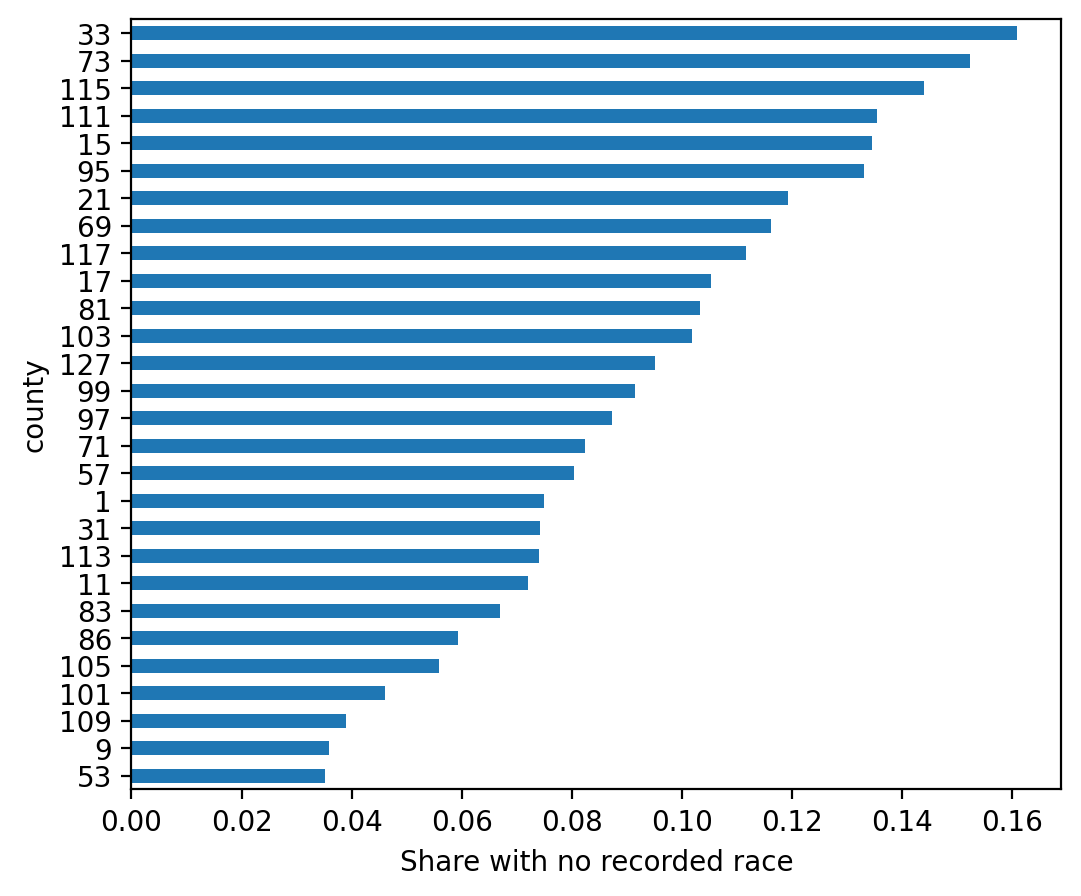

In [45]:
by_county = (
    flagged
    .groupby('county')
    .filter(lambda g: g.shape[0] >= 100)
    .groupby('county')['no_race']
    .mean()
    .sort_values()
)
by_county.plot.barh(
    figsize=(6, 5),
    xlabel='Share with no recorded race',
);

In [46]:
len(by_county), by_county.min(), by_county.max()

(28, 0.03508771929824561, 0.16091954022988506)

- Across 28 counties, the share with no race runs from 3.5 to 16.1 percent.
  Whether a race is recorded depends on where the voter lives.
- If missing values follow another feature, dropping those rows changes the
  make-up of the rows that remain.

### ❓ Question

An analyst must report the share of Florida voters who are white. Three ways
to handle the 874 voters with no race:

1. Drop them.
2. Keep them as their own category, `missing`.
3. Fill them with the most common race.

Which way gives the largest white share? Which way hides the problem?

<details><summary>Answer</summary>

Filling with the most common race gives the largest share, and it hides the
problem: 874 invented white voters look like real records.

</details>

### Dropping, keeping, or filling missing race

In [47]:
race = voters['race']
dropped = race.dropna().value_counts(normalize=True)
kept = race.fillna('missing').value_counts(normalize=True)
filled = race.fillna(race.mode()[0]).value_counts(normalize=True)

pd.concat(
    [dropped, kept, filled],
    axis=1,
    keys=['drop', 'own category', 'fill with mode'],
).round(3)

,drop,own category,fill with mode
race,,,
white,0.681,0.622,0.709
black,0.131,0.120,0.120
hispanic,0.131,0.119,0.119
other,0.035,0.032,0.032
asian,0.019,0.018,0.018
native,0.003,0.003,0.003
missing,NaN,0.087,NaN


- `.dropna()` removes missing values. `.fillna(x)` replaces them with `x`.
  `.mode()[0]` is the most common value. `normalize=True` turns counts into
  shares.
- `pd.concat(..., axis=1)` places tables **side by side**, matching rows by
  label. `keys=` names the columns.

- The white share is 0.681 after dropping, 0.622 with its own category, and
  0.709 after filling with the mode.
- Dropping assumes the missing voters look like the rest. The county
  comparison showed that they do not. Keeping a `missing` category is the most transparent. Filling
  with the mode is the worst of the three, because the invented values look
  real.

### Filling a numerical column

- For a numerical column, the usual fill is the mean or the median. It shrinks
  the spread, because every filled value sits in the middle.
- A **conditional** fill uses a group's own median, with `transform` from last
  lecture.

In [48]:
median_fill = voters['age'].fillna(voters['age'].median())
county_fill = (
    voters
    .groupby('county')['age']
    .transform(lambda s: s.fillna(s.median()))
)

voters['age'].std(), median_fill.std(), county_fill.std()

(18.809677824377832, 18.802154932161613, 18.802689074216012)

- Here only 8 of 10,000 ages are missing, so every choice gives the same
  results. The choice matters when many values are missing, as with race.

### Surnames as a source for race

- Every fill so far uses the same value for every voter, and ignores what else
  the file says about each one.
- The **surname** column also carries information about race. The Census publishes, for each common surname, the share of
  people with that name in each race group.
- Next lecture, we join the two tables and check how often a surname gives the
  right race.

## What we found

- **Congress:** in 1947, 134 Democrats sat to the right of the most liberal
  Republican. From 2003 on, none did. The Democrats lost their conservative
  wing and became more alike, and the Republicans moved right as a block.
- **Florida:** 8.7 percent of voters have no recorded race, and the share runs
  from 3.5 to 16.1 percent by county. Each way of handling them gives a
  different white share, from 0.622 to 0.709.

## Summary

| Goal | Write |
|---|---|
| A Figure and one Axes | `fig, ax = plt.subplots(figsize=(w, h))` |
| One row and three Axes on shared scales | `fig, axes = plt.subplots(1, 3, sharex=True, sharey=True)` |
| Axis labels and a title | `ax.set(xlabel=..., ylabel=..., title=...)` |
| Histogram with one colour per group | `sns.histplot(data=df, x='col', hue='g', binwidth=w, ax=ax)` |
| Compare shapes, not counts | `stat='density', common_norm=False` |
| Box plot or violin plot by group | `sns.boxplot(...)`, `sns.violinplot(...)` |
| Dots on a strip or in two dimensions | `sns.stripplot(...)`, `sns.scatterplot(data=df, x=, y=, hue=)` |
| Line through ordered points | `ax.plot(x, y)` |
| Quick chart of a DataFrame or Series | `df.plot()`, `df.plot.barh()` |
| Sharp figures on a high-resolution screen | `%config InlineBackend.figure_format = 'retina'` |
| 300 dpi for every saved figure | `plt.rcParams['savefig.dpi'] = 300` |
| Save a figure | `fig.savefig('name.png', dpi=300, bbox_inches='tight')` |
| Count missing values per column | `df.isna().sum()` |
| Counts that include missing values | `s.value_counts(dropna=False)` |
| Choose what counts as missing | `pd.read_csv(..., keep_default_na=False, na_values=[...])` |
| Remove or replace missing values | `s.dropna()`, `s.fillna(value)` |
| Tables side by side | `pd.concat([a, b], axis=1, keys=[...])` |